# Final Project:  The GM's blueprint: Quantifying the value of positional units to maximize win probability in the NFL


<br>
<br>


___

<br>

# Quantifying the value of positional units to maximize win probability in the NFL


* **Name**:  Baier, Jonas
* **Student number**:  0490373562

<br>

### Purpose:

* The primary objective of this validated machine learning analysis is to determine the contribution of a comprehensive set of offensive, defensive, and special teams efficiency metrics to the probability of winning an NFL game. The analysis concludes with a data-driven prioritization strategy for a General Manager to optimize salary cap allocation and draft strategy on based on positional value.
* The key **dependent variable** (DV) is the **game result** , operationalized as the home team’s margin of victory. In the machine learning section, this outcome is recoded as a binary indicator of a home win.
* The key **independent variable(s) (IVs)** are game-level differentials (Home Team Value - Away Team Value) aggregated from play-by-play data. These variables cover the spectrum of strategic decision-making:
* Passing Offense : **Differential Passing EPA** 
* Running Offense : **Differential Rushing EPA** 
* Situational Offense : **Differential Red Zone Score %** 
* Defensive Pressure : **Differential Sack Rate**
* Defensive Coverage : **Differential Defensive Pass EPA** 
* Turnover/Ball Security : **Differential Turnover Margin** 
* Situational Defense : **Differential 3rd Down Conversion %** 
* Special Teams : **Differential Field Goal EPA** 
* Game Control : **Differential Time of Possession (TOP)** 
* Discipline : **Differential Penalty Yards** 
* The raw Play-by-Play data contains over 5 Million cases (individual plays from 2017-2025). This will be aggregated into 2344 individual games. The analysis will calculate one dependent variable (DV) and ten comprehensive independent variables (IVs) from the raw data. 
<br>

### Dataset source:

The data comes from the [NFL](https://nfl.com) dataset from the [nflverse-data repository](https://github.com/nflverse/nflverse-data/releases)

The datasets are available for download [here](https://github.com/nflverse/nflverse-data/releases/tag/pbp).



In [1]:
import parse_data
df = parse_data.build_full_dataset("play_by_play")
df.describe()

,home_score,away_score,score_diff,home_win,diff_pass_epa,diff_rush_epa,diff_rz,diff_sack,diff_def_pass_epa,diff_turnover,diff_third_down,diff_top,diff_penalty,diff_st_epa
count,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2303.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,1815.000000
mean,23.779010,21.927474,1.851536,0.546075,0.004256,-0.010811,0.013712,0.002400,0.004256,0.091297,0.016274,14.301621,4.537543,0.112704
std,10.154494,9.842457,14.300929,0.497979,0.464265,0.288061,0.377507,0.059462,0.464265,3.537040,0.186460,524.570862,73.416342,1.719014
min,0.000000,0.000000,-49.000000,0.000000,-1.589303,-1.801176,-1.000000,-0.297297,-1.589303,-12.000000,-0.693182,-1598.000000,-244.000000,-6.347030
25%,17.000000,16.000000,-7.000000,0.000000,-0.306462,-0.200528,-0.250000,-0.035895,-0.306462,-2.000000,-0.108974,-356.500000,-44.000000,-0.778405
50%,24.000000,21.000000,2.000000,1.000000,0.000171,-0.021433,0.000000,0.001797,0.000171,0.000000,0.017857,20.000000,4.000000,0.105750
75%,30.000000,28.000000,10.000000,1.000000,0.300871,0.177973,0.250000,0.041667,0.300871,2.000000,0.136364,382.000000,52.000000,0.921132
max,70.000000,59.000000,50.000000,1.000000,2.159788,0.950608,1.000000,0.236842,2.159788,12.000000,0.625000,1666.000000,300.000000,6.267906


___

## Descriptive Statistics



This section establishes how competitive NFL games are and identifies the single offensive metric most closely associated with dominance.

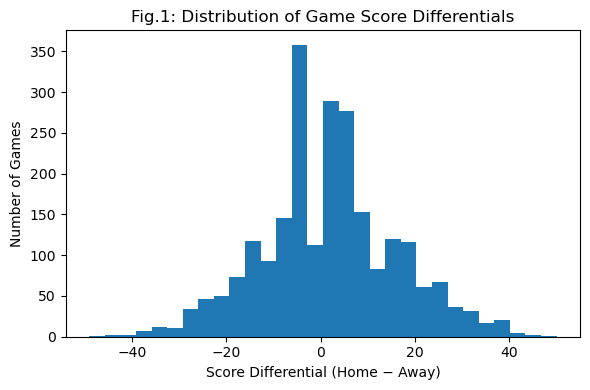

In [2]:
import descriptive
descriptive.figure_1_score_distribution(df)

Figure 1 shows that most NFL games are decided by small margins. The distribution is tightly centered near zero, with the majority of outcomes falling within one possession.

**Implication:**
Because games are rarely blowouts, even modest performance advantages can meaningfully change win probability. This makes efficiency and mistake avoidance more valuable than raw volume.

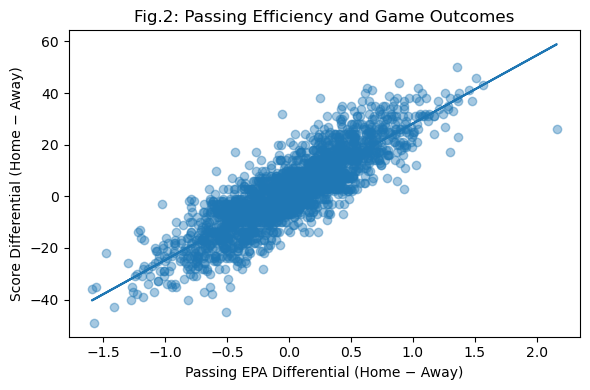

In [3]:
descriptive.figure_2_key_efficiency_relationship(df)

Figure 2 isolates the strongest bivariate relationship in the dataset: passing efficiency. As a team’s passing efficiency advantage increases, its scoring margin rises sharply.

**Implication:**
Among all single performance metrics, passing efficiency provides the highest return on investment. Resources allocated to quarterback play and pass protection have outsized effects on winning.

___

## Hypothesis Testing

This section tests whether key performance advantages are consistently associated with better outcomes. Only the two most informative and robust results are reported.

<Figure size 600x400 with 0 Axes>

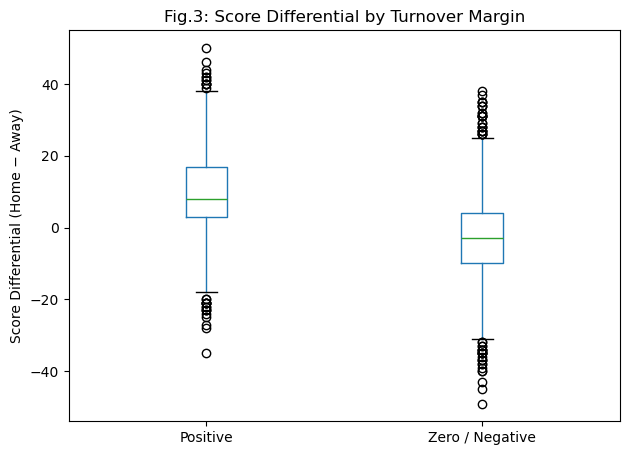

In [4]:
import classical
classical.plot_turnover_margin(df)

Figure 3 compares games with positive versus non-positive turnover margins. Teams that win the turnover battle achieve significantly higher score differentials, with a large and statistically robust gap (p < 0.001).

**Implication:**
Ball security is a foundational requirement for winning. Defensive takeaways and offensive mistake avoidance provide the most stable performance floor.

<Figure size 600x400 with 0 Axes>

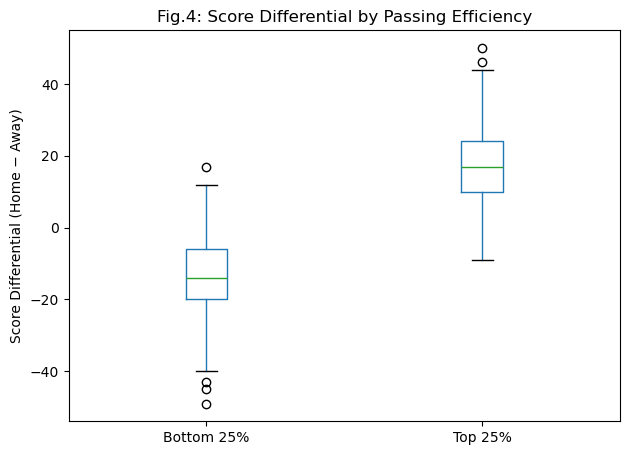

In [5]:
classical.plot_passing_epa(df)

Figure 4 compares the top and bottom quartiles of passing efficiency to focus on typical, not extreme, games. Teams in the top quartile dramatically outperform those in the bottom quartile.

**Implication:**
The difference between average and elite passing is the single largest separator between strong and weak teams. Investment in high-level quarterback play is statistically justified.

___

## Machine Learning

This section evaluates whether game-level performance metrics can reliably predict wins and identifies how different advantages combine when considered simultaneously. The emphasis is on clarity and interpretability rather than model complexity.

A validated win-probability model is estimated and tested on unseen games. To reduce redundancy between related metrics, dimensionality reduction is applied to capture broader performance patterns.

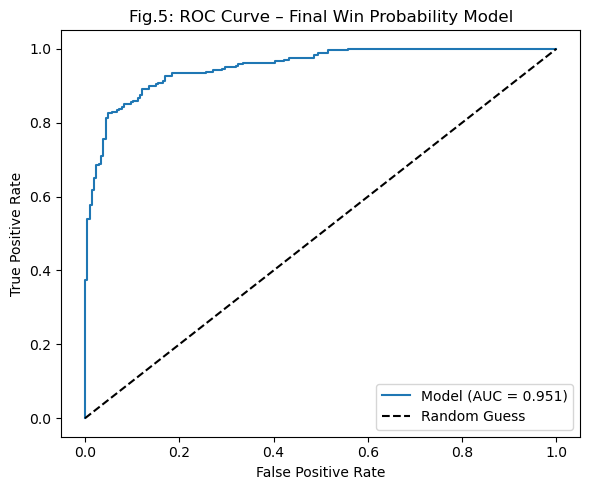

In [6]:
import machine as ml
ml_results = ml.run_improved_machine_learning(df)
ml.plot_final_roc_curve(ml_results)

Figure 5 shows how well the final model distinguishes wins from losses across all decision thresholds. The curve lies well above the diagonal reference line, indicating strong and stable predictive accuracy on the test set.

**Implication:**
Game-level efficiency metrics contain clear, repeatable signals about winning. The model’s performance confirms that these metrics provide a reliable basis for evaluating team strength.

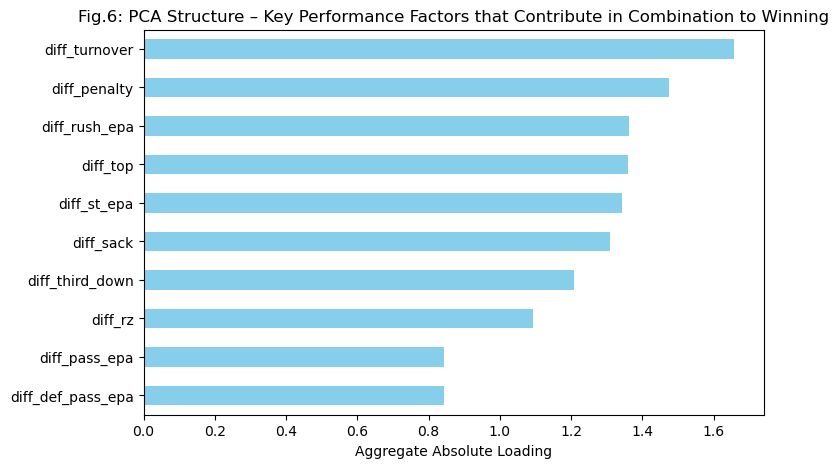

In [7]:
ml.plot_pca_loadings(ml_results["model"])

Figure 6 summarizes which types of performance most strongly influence winning when all metrics are considered together. Rather than pointing to a single dominant statistic, the results show that wins emerge from coordinated advantages across ball security, discipline, situational efficiency, and overall game control.

Passing efficiency remains foundational to success because it overlaps strongly with several other metrics. Therefore, its influence is spread across multiple performance dimensions, but its value is only maximized when paired with complementary strengths such as limiting turnovers and penalties.

**Implication:**
Teams do not win by excelling in only one area. Sustainable success comes from elite passing supported by advantages in discipline, efficiency, and game control.

___

## Summary

NFL games are typically decided by small margins, making efficiency and mistake avoidance decisive factors in winning. Among all individual performance metrics, passing efficiency is the strongest and most consistent predictor of game outcomes, clearly separating strong teams from weak ones.

However, machine learning results show that wins are not driven by a single statistic alone. Instead, success emerges from clusters of related advantages, most notably passing efficiency combined with ball security, discipline, and situational control. Teams that pair elite passing with low turnovers and penalties achieve the highest and most stable win probabilities.

**Strategic takeaway:**
A General Manager seeking to maximize win probability should prioritize quarterback play and passing efficiency, while simultaneously investing in systems that protect the ball, reduce penalties, and sustain drives. Winning is not about one statistic, but about aligning multiple high-impact performance dimensions.